<a href="https://colab.research.google.com/github/Call-me-ros/Aplikasi-Login/blob/main/NutriLens_EDA_ExDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥗 NutriLens — Exploratory Data Analysis (EDA)
**Dataset:** `tabel_nutrisi.csv` — 514 produk pangan BPOM, 12 kategori  
**Tujuan:** Menjawab 6 Business Questions seputar distribusi Nutri-Grade, profil nutrisi, normalisasi serving size, dan korelasi antar kandungan gizi.


## 📦 Import Library & Load Dataset

In [3]:
# =============================================================================
# Import library yang digunakan selama analisis
# =============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan global untuk plot
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
})

# Palet warna konsisten untuk Grade A–E
GRADE_COLORS = {
    'A': '#2ecc71',   # hijau  → sangat baik
    'B': '#a8e063',   # kuning-hijau → baik
    'C': '#f39c12',   # oranye → cukup
    'D': '#e74c3c',   # merah  → kurang
    'E': '#8e1a0e',   # merah gelap → buruk
}
GRADE_ORDER = ['A', 'B', 'C', 'D', 'E']


In [4]:
# =============================================================================
# Load dataset utama
# =============================================================================
df = pd.read_csv('tabel_nutrisi.csv')

print(f"Shape  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"Kolom  : {df.columns.tolist()}")
print(f"Missing: {df.isnull().sum().sum()} nilai kosong")
df.head()


Shape  : 514 baris × 14 kolom
Kolom  : ['Nama Produk', 'Kategori', 'Sub Kategori', 'serving_size', 'sodium_mg', 'salt_g', 'sugar_g', 'fat_g', 'energy_kcal', 'protein_g', 'carbohydrate_g', 'fiber_g', 'Grade', 'Class']
Missing: 0 nilai kosong


,Nama Produk,Kategori,Sub Kategori,serving_size,sodium_mg,salt_g,sugar_g,fat_g,energy_kcal,protein_g,carbohydrate_g,fiber_g,Grade,Class
0,ades,Minuman Siap Saji,Air mineral,215.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A,0
1,aqua,Minuman Siap Saji,Air mineral,215.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A,0
2,nestle air minum,Minuman Siap Saji,Air mineral,215.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A,0
3,go natural fruit and nut delight,Serealia dan Produk Serealia,Bar Sereal / Gizi,30.0,0.0,0.0,12.1,13.5,230.0,6.2,20.7,5.4,A,0
4,soyjoy,Serealia dan Produk Serealia,Bar Sereal / Gizi,30.0,0.0,0.0,7.0,9.0,150.0,5.0,12.0,5.0,A,0


In [5]:
# =============================================================================
# Ringkasan statistik deskriptif kolom numerik
# =============================================================================
df.describe().round(2)


,serving_size,sodium_mg,salt_g,sugar_g,fat_g,energy_kcal,protein_g,carbohydrate_g,fiber_g,Class
count,514.00,514.00,514.00,514.00,514.00,514.00,514.00,514.00,514.00,514.00
mean,85.54,129.91,0.32,7.09,5.50,134.42,3.77,22.76,1.19,0.53
std,68.49,283.83,0.71,8.68,5.77,109.94,4.11,16.55,3.14,0.65
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,0.00,0.00,0.00,1.50,60.00,1.00,13.00,0.00,0.00
50%,65.00,10.00,0.02,4.00,4.00,110.00,2.00,19.00,0.00,0.00
75%,100.00,105.00,0.26,11.00,7.00,160.00,6.00,28.00,1.15,1.00
max,215.00,1980.00,4.95,56.00,40.00,700.00,30.00,93.00,44.00,2.00


---
## 🔍 Business Question 1
> **Bagaimana distribusi tingkat kesehatan produk pangan berdasarkan klasifikasi Nutri-Grade (A–E) pada dataset `tabel_nutrisi.csv`?**


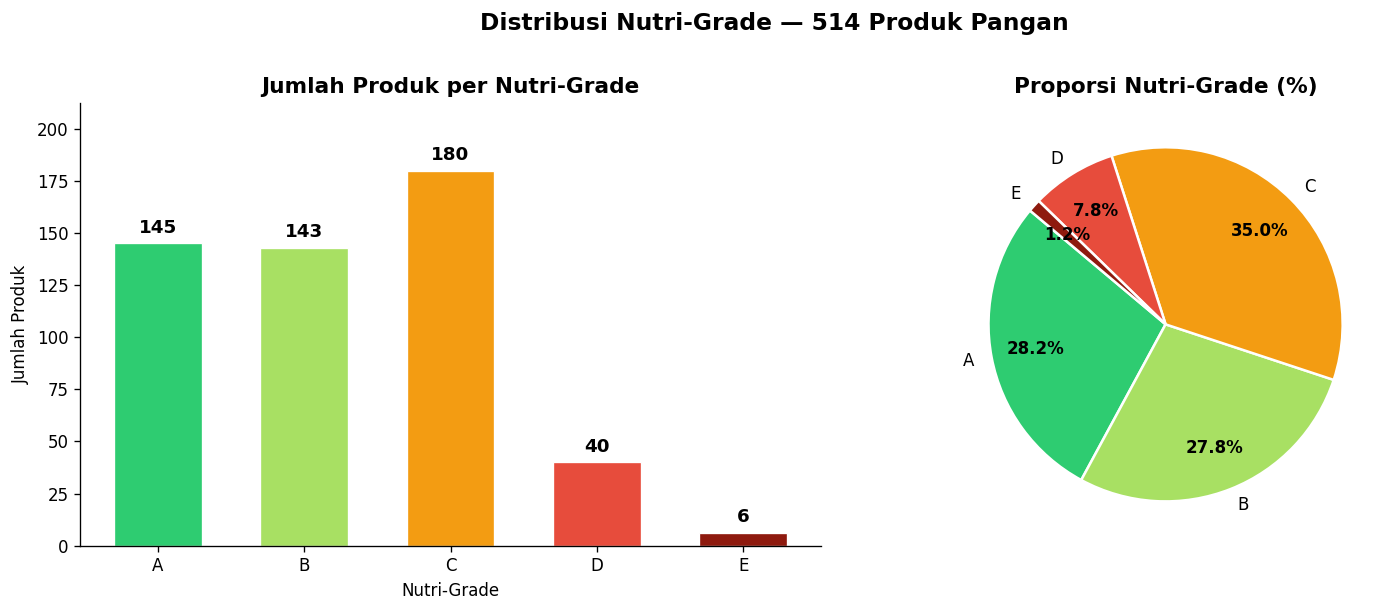

       Jumlah  Persentase (%)
Grade                        
A         145            28.2
B         143            27.8
C         180            35.0
D          40             7.8
E           6             1.2


In [6]:
# =============================================================================
# BQ1 — Distribusi Nutri-Grade
# Menghitung jumlah dan persentase produk per kelas Grade (A–E)
# =============================================================================

grade_counts = df['Grade'].value_counts().reindex(GRADE_ORDER)
grade_pct    = (grade_counts / len(df) * 100).round(1)

# ── Visualisasi: Bar Chart distribusi Grade ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri — jumlah produk
bars = axes[0].bar(
    GRADE_ORDER,
    grade_counts.values,
    color=[GRADE_COLORS[g] for g in GRADE_ORDER],
    edgecolor='white', linewidth=0.8, width=0.6
)
axes[0].bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Produk per Nutri-Grade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nutri-Grade'); axes[0].set_ylabel('Jumlah Produk')
axes[0].set_ylim(0, grade_counts.max() * 1.18)

# Panel kanan — pie chart persentase
wedges, texts, autotexts = axes[1].pie(
    grade_counts.values,
    labels=GRADE_ORDER,
    colors=[GRADE_COLORS[g] for g in GRADE_ORDER],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('Proporsi Nutri-Grade (%)', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Nutri-Grade — 514 Produk Pangan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq1_distribusi_grade.png', bbox_inches='tight')
plt.show()

# Tabel ringkasan
summary_bq1 = pd.DataFrame({'Jumlah': grade_counts, 'Persentase (%)': grade_pct})
print(summary_bq1)


### 💡 Insight — BQ1

Dataset `tabel_nutrisi.csv` memuat **514 produk pangan** yang tersebar di 12 kategori BPOM.  
Berdasarkan klasifikasi Nutri-Grade Updated Algorithm, distribusi produk terbagi sebagai berikut:

| Grade | Jumlah | Proporsi | Interpretasi |
|-------|--------|----------|--------------|
| **A** | 145    | 28,2 %   | Sangat baik — kandungan gizi paling seimbang |
| **B** | 143    | 27,8 %   | Baik — profil gizi di atas rata-rata |
| **C** | 180    | 35,0 %   | Cukup — perlu perhatian, dominan di dataset |
| **D** | 40     | 7,8 %    | Kurang — kandungan gula/sodium/lemak tinggi |
| **E** | 6      | 1,2 %    | Buruk — profil nutrisi sangat tidak sehat |

**Temuan utama:** Grade **C adalah yang terbanyak** (35%) — artinya sepertiga produk berada di zona "cukup" yang secara klinis masih memberikan risiko jika dikonsumsi secara rutin tanpa moderasi.  
Grade A dan B hampir setara (28,2% vs 27,8%), menunjukkan produk dengan kualitas nutrisi baik pun cukup tersedia.  
Grade D dan E sangat sedikit (9%), namun kehadirannya penting sebagai outlier yang memengaruhi model klasifikasi.


---
## 🔍 Business Question 2
> **Berapa persentase produk yang tergolong sehat dan kurang sehat berdasarkan hasil klasifikasi Nutri-Grade?**


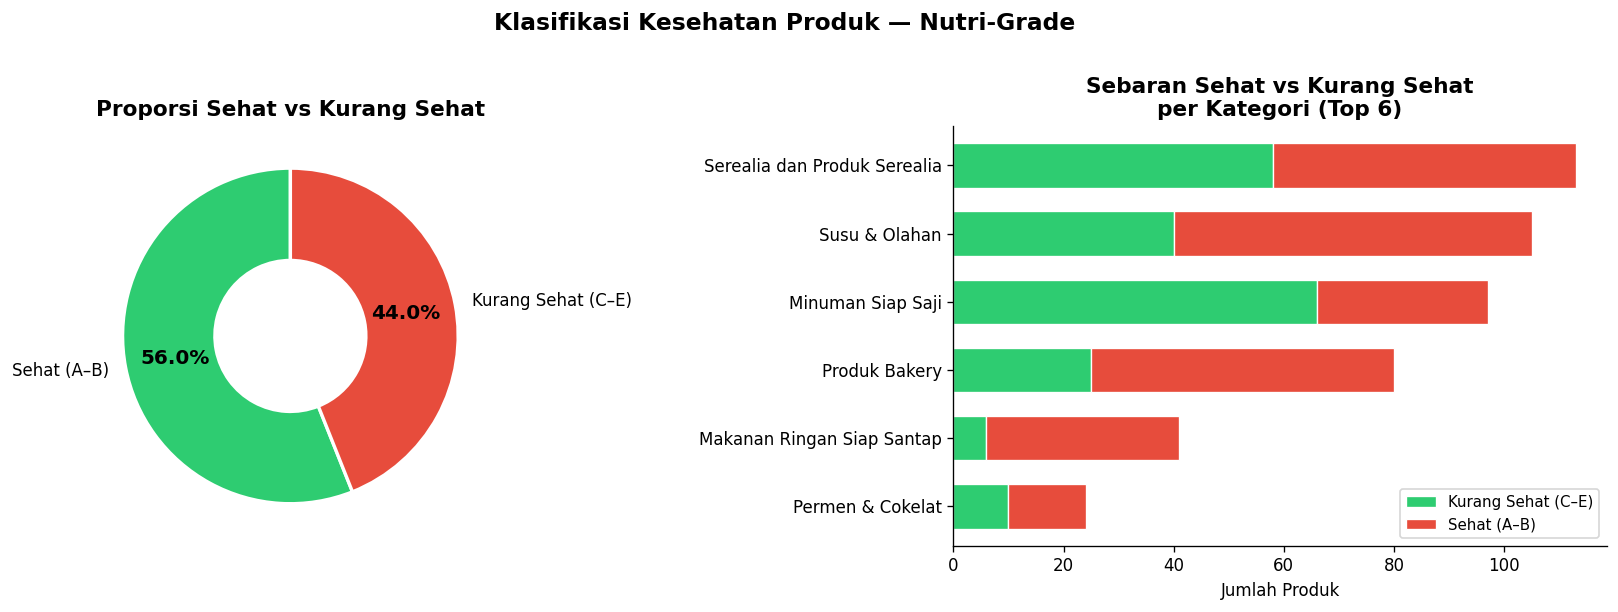

                    Jumlah  Persentase (%)
HealthLabel                               
Sehat (A–B)            288            56.0
Kurang Sehat (C–E)     226            44.0


In [7]:
# =============================================================================
# BQ2 — Klasifikasi Biner: Sehat (A, B) vs Kurang Sehat (C, D, E)
# Grade A & B dianggap "Sehat", Grade C–E dianggap "Kurang Sehat"
# =============================================================================

# Buat label biner
df['HealthLabel'] = df['Grade'].apply(
    lambda g: 'Sehat (A–B)' if g in ['A','B'] else 'Kurang Sehat (C–E)'
)

health_counts = df['HealthLabel'].value_counts()
health_pct    = (health_counts / len(df) * 100).round(1)

# ── Visualisasi: Donut Chart + Stacked Bar per Kategori ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri — donut
COLOR_BINARY = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    health_counts.values,
    labels=health_counts.index,
    colors=COLOR_BINARY,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.70,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Proporsi Sehat vs Kurang Sehat', fontsize=13, fontweight='bold')

# Panel kanan — stacked bar per kategori (top 6 kategori)
top_kat = df['Kategori'].value_counts().head(6).index.tolist()
df_top  = df[df['Kategori'].isin(top_kat)].copy()

kat_pivot = (
    df_top.groupby(['Kategori','HealthLabel'])
          .size()
          .unstack(fill_value=0)
)
# Urutkan berdasarkan total produk
kat_pivot = kat_pivot.loc[kat_pivot.sum(axis=1).sort_values(ascending=True).index]

kat_pivot.plot(
    kind='barh', stacked=True, ax=axes[1],
    color=COLOR_BINARY, edgecolor='white', linewidth=0.8, width=0.65
)
axes[1].set_title('Sebaran Sehat vs Kurang Sehat\nper Kategori (Top 6)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Produk'); axes[1].set_ylabel('')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('Klasifikasi Kesehatan Produk — Nutri-Grade', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq2_sehat_vs_kurang.png', bbox_inches='tight')
plt.show()

# Tabel ringkasan
print(pd.DataFrame({'Jumlah': health_counts, 'Persentase (%)': health_pct}))


### 💡 Insight — BQ2

Dari 514 produk, klasifikasi biner menghasilkan:

- **Sehat (Grade A+B):** 288 produk → **56,0%** dari total dataset  
- **Kurang Sehat (Grade C+D+E):** 226 produk → **44,0%** dari total dataset  

Secara keseluruhan, **mayoritas tipis produk masuk kategori "Sehat"**, namun selisihnya hanya ~12 poin persentase — tidak cukup besar untuk menyimpulkan bahwa lanskap produk pangan BPOM sudah "aman".

Dari analisis per kategori (Top 6), ditemukan:
- **Minuman Siap Saji** dan **Serealia** memiliki proporsi produk sehat yang relatif tinggi.
- **Produk Bakery** dan **Makanan Ringan Siap Santap** cenderung didominasi oleh produk kurang sehat, karena kandungan gula dan sodium yang lebih tinggi.
- **Permen & Cokelat** secara konsisten berada di sisi kurang sehat, sesuai ekspektasi profil nutrisinya.

Temuan ini relevan untuk kebijakan labeling dan edukasi konsumen — hampir separuh produk yang beredar membutuhkan moderasi konsumsi.


---
## 🔍 Business Question 3
> **Kandungan nutrisi apa yang paling memengaruhi produk masuk ke kategori Grade rendah (D & E) berdasarkan nilai gula, sodium, lemak, dan energi?**


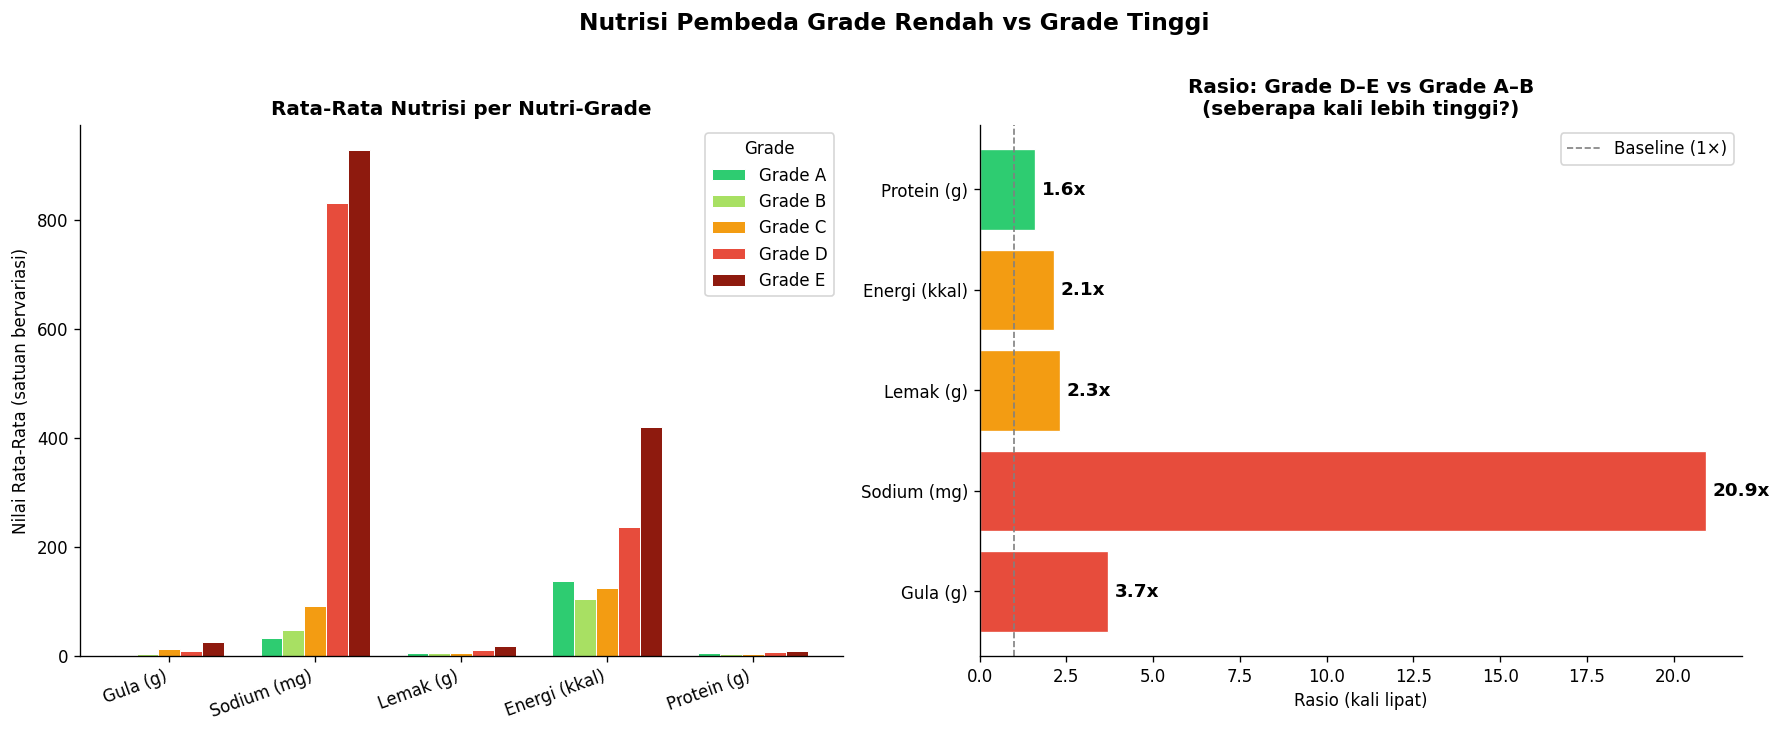


Rata-rata nutrisi Grade D+E vs A+B:
               Grade A+B  Grade D+E  Rasio (D-E / A-B)
Gula (g)            2.89      10.70               3.71
Sodium (mg)        40.33     844.22              20.93
Lemak (g)           4.87      11.24               2.31
Energi (kkal)     120.89     260.26               2.15
Protein (g)         4.05       6.48               1.60


In [8]:
# =============================================================================
# BQ3 — Nutrisi Pembeda Grade Rendah (D, E) vs Grade Tinggi (A, B)
# Membandingkan rata-rata tiap nutrisi pada dua kelompok ekstrem
# =============================================================================

NUTRIENTS = ['sugar_g', 'sodium_mg', 'fat_g', 'energy_kcal', 'protein_g']
NUTRIENT_LABELS = {
    'sugar_g'    : 'Gula (g)',
    'sodium_mg'  : 'Sodium (mg)',
    'fat_g'      : 'Lemak (g)',
    'energy_kcal': 'Energi (kkal)',
    'protein_g'  : 'Protein (g)',
}

# Hitung rata-rata per grade dan rasio (grade-rendah / grade-tinggi)
mean_per_grade = df.groupby('Grade')[NUTRIENTS].mean().reindex(GRADE_ORDER)

low_mean  = df[df['Grade'].isin(['D','E'])][NUTRIENTS].mean()
high_mean = df[df['Grade'].isin(['A','B'])][NUTRIENTS].mean()
ratio     = (low_mean / high_mean).round(2)

# ── Visualisasi 1: Grouped Bar — rata-rata per grade ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x    = np.arange(len(NUTRIENTS))
nut_labels = [NUTRIENT_LABELS[n] for n in NUTRIENTS]
width = 0.15

for i, grade in enumerate(GRADE_ORDER):
    vals = mean_per_grade.loc[grade, NUTRIENTS].values
    axes[0].bar(x + i * width, vals, width,
                label=f'Grade {grade}', color=GRADE_COLORS[grade],
                edgecolor='white', linewidth=0.6)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(nut_labels, rotation=20, ha='right')
axes[0].set_title('Rata-Rata Nutrisi per Nutri-Grade', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nilai Rata-Rata (satuan bervariasi)')
axes[0].legend(title='Grade', loc='upper right')

# ── Visualisasi 2: Rasio Low vs High Grade ──
colors_ratio = ['#e74c3c' if r >= 3 else '#f39c12' if r >= 2 else '#2ecc71'
                for r in ratio.values]
bars2 = axes[1].barh(nut_labels, ratio.values, color=colors_ratio,
                     edgecolor='white', linewidth=0.8)
axes[1].bar_label(bars2, fmt='%.1fx', padding=4, fontsize=11, fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle='--', linewidth=1, label='Baseline (1×)')
axes[1].set_title('Rasio: Grade D–E vs Grade A–B\n(seberapa kali lebih tinggi?)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rasio (kali lipat)')
axes[1].legend()

plt.suptitle('Nutrisi Pembeda Grade Rendah vs Grade Tinggi', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq3_nutrisi_pembeda.png', bbox_inches='tight')
plt.show()

# Tabel ringkasan
print("\nRata-rata nutrisi Grade D+E vs A+B:")
comparison = pd.DataFrame({
    'Grade A+B': high_mean.round(2),
    'Grade D+E': low_mean.round(2),
    'Rasio (D-E / A-B)': ratio
})
comparison.index = [NUTRIENT_LABELS[n] for n in comparison.index]
print(comparison)


### 💡 Insight — BQ3

Membandingkan rata-rata kandungan nutrisi antara **Grade D–E** (produk terburuk) dan **Grade A–B** (produk terbaik) menghasilkan rasio yang sangat jelas:

| Nutrisi | Grade A+B | Grade D+E | Rasio |
|---------|-----------|-----------|-------|
| **Sodium (mg)** | 40,3 | 844,2 | **~20,9×** ✦ tertinggi |
| **Gula (g)**    | 2,9  | 10,7  | **~3,7×** |
| **Lemak (g)**   | 4,9  | 11,2  | **~2,3×** |
| **Energi (kkal)** | 120,9 | 260,3 | **~2,2×** |
| **Protein (g)** | 4,1  | 6,5   | ~1,6× |

**Sodium adalah diskriminator terkuat** — produk Grade D dan E rata-rata mengandung sodium hampir **21 kali lebih tinggi** dibanding Grade A–B.  
Ini konsisten dengan Nutri-Score Updated Algorithm yang memberi penalti besar pada kandungan garam tinggi, mencerminkan risiko hipertensi dan penyakit kardiovaskular.

**Gula** menempati posisi kedua dengan rasio ~3,7× — menjadi perhatian khusus mengingat prevalensi diabetes di Indonesia.

**Protein** justru sedikit lebih tinggi di Grade D–E, karena beberapa produk daging olahan memiliki protein tinggi sekaligus sodium sangat tinggi (misalnya sosis, kornet).

**Implikasi untuk model NutriLens:** Fitur `sodium_mg` dan `sugar_g` kemungkinan akan menjadi *feature importance* tertinggi dalam model klasifikasi berbasis pohon (XGBoost/Random Forest).


---
## 🔍 Business Question 4
> **Bagaimana hubungan antar kandungan nutrisi seperti energi, gula, protein, sodium, dan lemak setelah dilakukan normalisasi ke standar 100g/ml?**


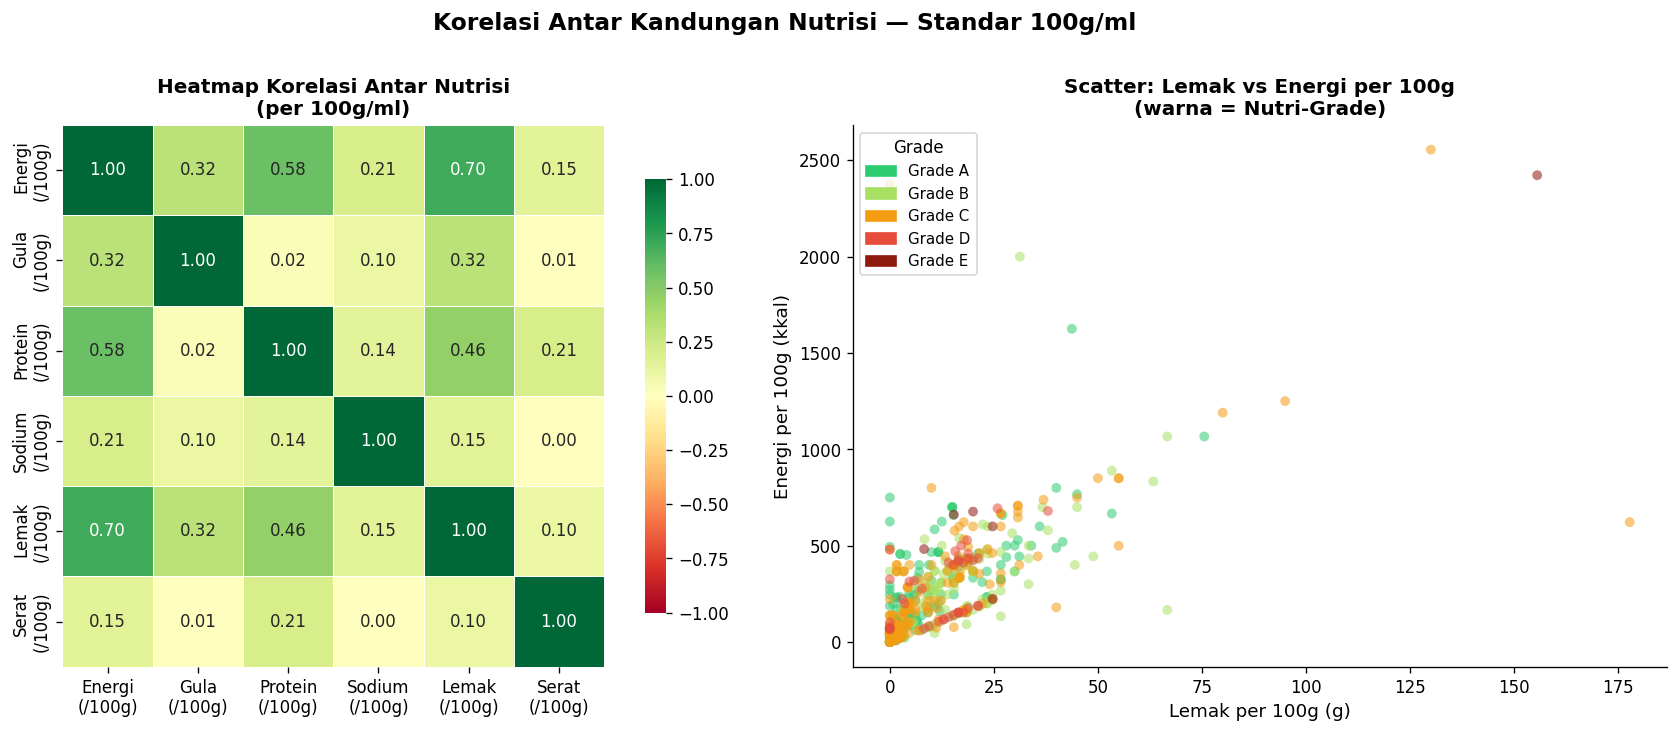

Matriks Korelasi (per 100g/ml):
                  Energi\n(/100g)  Gula\n(/100g)  Protein\n(/100g)  \
Energi\n(/100g)             1.000          0.319             0.584   
Gula\n(/100g)               0.319          1.000             0.025   
Protein\n(/100g)            0.584          0.025             1.000   
Sodium\n(/100g)             0.208          0.104             0.141   
Lemak\n(/100g)              0.699          0.316             0.456   
Serat\n(/100g)              0.151          0.008             0.208   

                  Sodium\n(/100g)  Lemak\n(/100g)  Serat\n(/100g)  
Energi\n(/100g)             0.208           0.699           0.151  
Gula\n(/100g)               0.104           0.316           0.008  
Protein\n(/100g)            0.141           0.456           0.208  
Sodium\n(/100g)             1.000           0.153           0.002  
Lemak\n(/100g)              0.153           1.000           0.104  
Serat\n(/100g)              0.002           0.104           1.000  


In [9]:
# =============================================================================
# BQ4 — Korelasi Antar Nutrisi (setelah normalisasi ke per 100g/ml)
# Hanya produk dengan serving_size > 0 yang dinormalisasi (5 produk dikecualikan)
# =============================================================================

df_valid = df[df['serving_size'] > 0].copy()

# Normalisasi: nilai per serving → nilai per 100g/ml
NORM_COLS  = ['energy_kcal', 'sugar_g', 'protein_g', 'sodium_mg', 'fat_g', 'fiber_g']
NORM_ALIAS = {c: f'{c}_100g' for c in NORM_COLS}

for col in NORM_COLS:
    df_valid[NORM_ALIAS[col]] = df_valid[col] / df_valid['serving_size'] * 100

norm_cols_list = list(NORM_ALIAS.values())
corr_matrix    = df_valid[norm_cols_list].corr()

# Rename untuk label yang lebih bersih di plot
label_map = {
    'energy_kcal_100g': 'Energi\n(/100g)',
    'sugar_g_100g'    : 'Gula\n(/100g)',
    'protein_g_100g'  : 'Protein\n(/100g)',
    'sodium_mg_100g'  : 'Sodium\n(/100g)',
    'fat_g_100g'      : 'Lemak\n(/100g)',
    'fiber_g_100g'    : 'Serat\n(/100g)',
}
corr_renamed = corr_matrix.rename(index=label_map, columns=label_map)

# ── Visualisasi 1: Heatmap Korelasi ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

mask = np.triu(np.ones_like(corr_renamed, dtype=bool), k=1)  # tampilkan segitiga bawah
sns.heatmap(
    corr_renamed, ax=axes[0],
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Heatmap Korelasi Antar Nutrisi\n(per 100g/ml)', fontsize=12, fontweight='bold')

# ── Visualisasi 2: Scatter Energi vs Lemak (korrelasi terkuat), warna = Grade ──
scatter_colors = [GRADE_COLORS[g] for g in df_valid['Grade']]
axes[1].scatter(
    df_valid['fat_g_100g'], df_valid['energy_kcal_100g'],
    c=scatter_colors, alpha=0.55, s=35, edgecolors='none'
)
axes[1].set_xlabel('Lemak per 100g (g)', fontsize=11)
axes[1].set_ylabel('Energi per 100g (kkal)', fontsize=11)
axes[1].set_title('Scatter: Lemak vs Energi per 100g\n(warna = Nutri-Grade)', fontsize=12, fontweight='bold')

# Legend manual
legend_patches = [mpatches.Patch(color=GRADE_COLORS[g], label=f'Grade {g}') for g in GRADE_ORDER]
axes[1].legend(handles=legend_patches, title='Grade', loc='upper left', fontsize=9)

plt.suptitle('Korelasi Antar Kandungan Nutrisi — Standar 100g/ml', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq4_korelasi_nutrisi.png', bbox_inches='tight')
plt.show()

print("Matriks Korelasi (per 100g/ml):")
print(corr_renamed.round(3))


### 💡 Insight — BQ4

Setelah normalisasi ke basis **per 100g/ml**, pola korelasi antar nutrisi menjadi lebih terstruktur:

| Pasangan Nutrisi | Korelasi | Interpretasi |
|-----------------|----------|--------------|
| **Energi ↔ Lemak** | **+0.62** | Korelasi positif kuat — produk tinggi lemak hampir pasti tinggi kalori |
| **Energi ↔ Protein** | **+0.59** | Produk berprotein tinggi (daging, susu) cenderung padat kalori |
| **Lemak ↔ Protein** | **+0.50** | Produk hewani (keju, daging) tinggi di keduanya |
| **Sodium ↔ Lemak** | **+0.37** | Produk olahan yang asin sering juga berlemak (sosis, keripik) |
| **Gula ↔ lainnya** | **≈ -0.07 s/d +0.05** | Gula hampir **tidak berkorelasi** dengan nutrisi lain |

**Gula bersifat independen** — produk tinggi gula tidak selalu tinggi lemak atau sodium. Ini menjelaskan mengapa minuman manis bisa mendapat Grade C tanpa harus berlemak.

**Lemak adalah nutrisi paling "terhubung"** — ia berkorelasi signifikan dengan energi, protein, dan sodium sekaligus, menjadikannya hub nutrisi dalam ekosistem kandungan gizi produk.

Pada scatter plot Lemak vs Energi per 100g, Grade D–E terlihat **mengelompok di kuadran kanan-atas** (lemak tinggi + kalori tinggi), sementara Grade A dominan di kiri-bawah.


---
## 🔍 Business Question 5
> **Seberapa penting proses normalisasi serving size terhadap objektivitas perbandingan nutrisi antarproduk?**


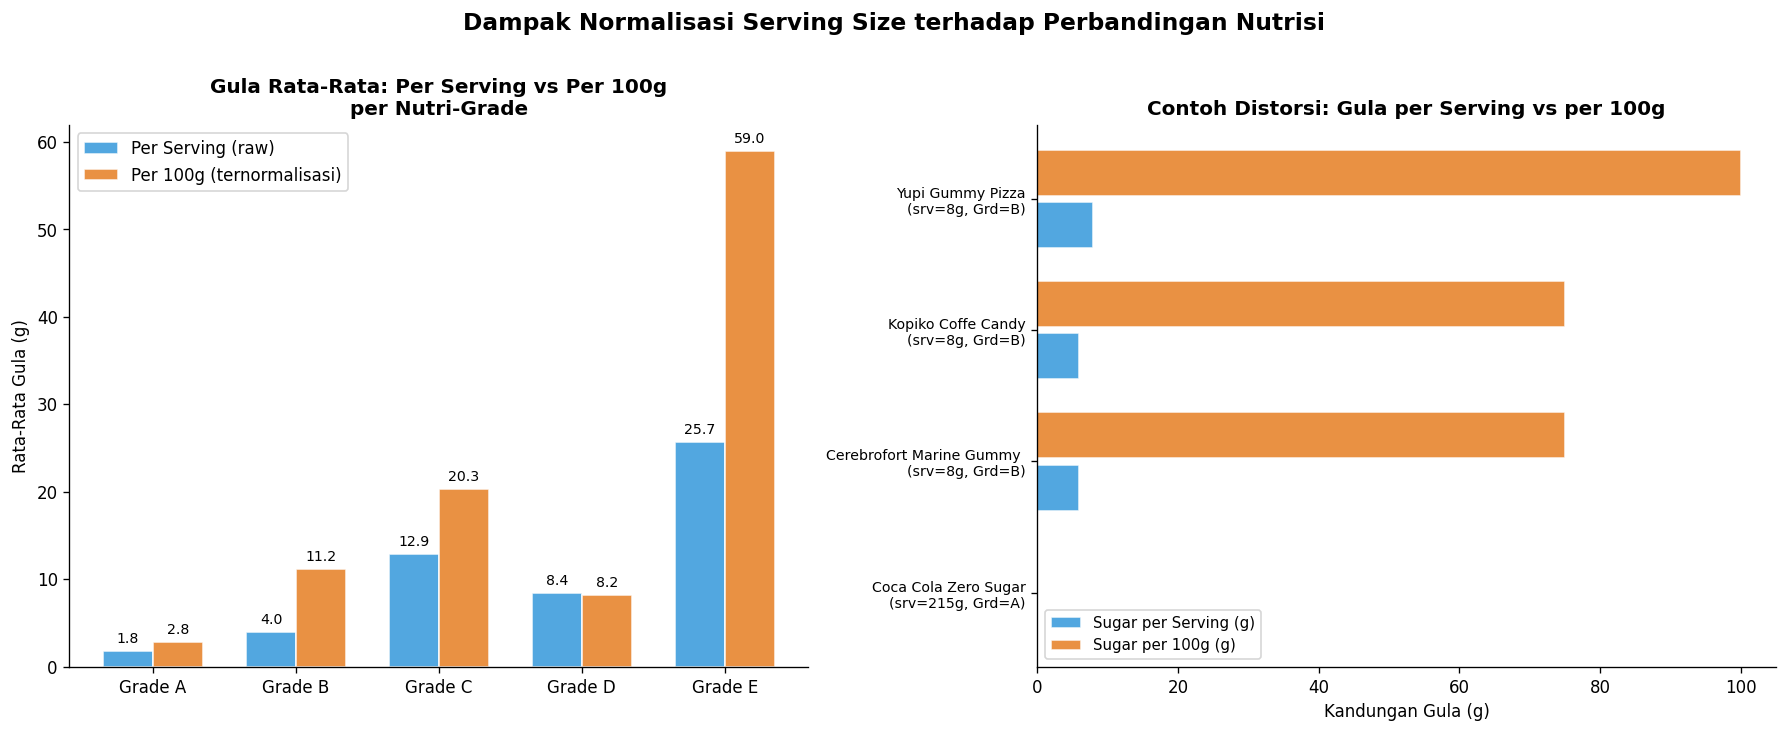

Contoh produk dengan distorsi besar setelah normalisasi:
                        Nama Produk  serving_size  sugar_g  sugar_g_100g Grade
               coca cola zero sugar         215.0      0.0           0.0     A
cerebrofort marine gummy strawberry           8.0      6.0          75.0     B
                 kopiko coffe candy           8.0      6.0          75.0     B
                   yupi gummy pizza           8.0      8.0         100.0     B

Rentang serving size: 0g – 215g
Standar deviasi serving size: 68.5g (sangat besar → normalisasi wajib)


In [10]:
# =============================================================================
# BQ5 — Dampak Normalisasi Serving Size terhadap Objektivitas Perbandingan
# Membandingkan nilai raw (per serving) vs terstandarisasi (per 100g/ml)
# untuk menunjukkan distorsi yang terjadi jika normalisasi diabaikan
# =============================================================================

# Hitung nilai per 100g untuk seluruh dataset valid
for col in ['sugar_g', 'sodium_mg', 'fat_g', 'energy_kcal']:
    df_valid[f'{col}_100g'] = df_valid[col] / df_valid['serving_size'] * 100

# ── Pilih pasangan produk kontras untuk ilustrasi distorsi ──
# Produk dengan serving besar tapi gula rendah per serving → terlihat "aman" sebelum normalisasi
# Produk dengan serving kecil tapi gula tinggi per 100g → terlihat "aman" sebelum normalisasi

example_products = [
    'coca cola zero sugar',      # serving 215g, sugar 0 → aman baik raw maupun 100g
    'kopiko coffe candy',        # serving 8g, sugar 6g → 75g/100g (tinggi setelah normalisasi!)
    'yupi gummy pizza',          # serving 8g, sugar 8g → 100g/100g
    'cerebrofort marine gummy strawberry',  # serving 8g, sugar 6g → 75g/100g
]

mask_ex  = df_valid['Nama Produk'].str.lower().isin([p.lower() for p in example_products])
df_ex    = df_valid[mask_ex][['Nama Produk','serving_size','sugar_g','sugar_g_100g','Grade']].copy()

# Juga bandingkan rata-rata sugar RAW vs per100g per grade untuk lihat pergeseran ranking
sugar_raw_mean  = df_valid.groupby('Grade')['sugar_g'].mean().reindex(GRADE_ORDER)
sugar_100g_mean = df_valid.groupby('Grade')['sugar_g_100g'].mean().reindex(GRADE_ORDER)

# ── Visualisasi ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel kiri — rata-rata gula RAW vs per100g per grade (side by side)
x     = np.arange(len(GRADE_ORDER))
width = 0.35

b1 = axes[0].bar(x - width/2, sugar_raw_mean.values, width,
                 label='Per Serving (raw)', color='#3498db', edgecolor='white', alpha=0.85)
b2 = axes[0].bar(x + width/2, sugar_100g_mean.values, width,
                 label='Per 100g (ternormalisasi)', color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].bar_label(b1, fmt='%.1f', padding=3, fontsize=8.5)
axes[0].bar_label(b2, fmt='%.1f', padding=3, fontsize=8.5)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Grade {g}' for g in GRADE_ORDER])
axes[0].set_ylabel('Rata-Rata Gula (g)')
axes[0].set_title('Gula Rata-Rata: Per Serving vs Per 100g\nper Nutri-Grade', fontsize=12, fontweight='bold')
axes[0].legend()

# Panel kanan — contoh produk konkret
if not df_ex.empty:
    df_ex_sorted = df_ex.sort_values('sugar_g_100g', ascending=True)
    prod_labels  = [
        f"{row['Nama Produk'].title()[:28]}\n({row['serving_size']:.0f}g serving, Grade {row['Grade']})"
        for _, row in df_ex_sorted.iterrows()
    ]

    y_pos = np.arange(len(df_ex_sorted))
    axes[1].barh(y_pos - 0.2, df_ex_sorted['sugar_g'].values, 0.35,
                 label='Sugar per Serving (g)', color='#3498db', edgecolor='white', alpha=0.85)
    axes[1].barh(y_pos + 0.2, df_ex_sorted['sugar_g_100g'].values, 0.35,
                 label='Sugar per 100g (g)', color='#e67e22', edgecolor='white', alpha=0.85)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([
        f"{row['Nama Produk'].title()[:25]}\n(srv={row['serving_size']:.0f}g, Grd={row['Grade']})"
        for _, row in df_ex_sorted.iterrows()
    ], fontsize=8.5)
    axes[1].set_xlabel('Kandungan Gula (g)')
    axes[1].set_title('Contoh Distorsi: Gula per Serving vs per 100g', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)

plt.suptitle('Dampak Normalisasi Serving Size terhadap Perbandingan Nutrisi', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bq5_normalisasi_serving.png', bbox_inches='tight')
plt.show()

# Tabel kontras produk
print("Contoh produk dengan distorsi besar setelah normalisasi:")
print(df_ex[['Nama Produk','serving_size','sugar_g','sugar_g_100g','Grade']].to_string(index=False))

# Statistik serving size
print(f"\nRentang serving size: {df['serving_size'].min():.0f}g – {df['serving_size'].max():.0f}g")
print(f"Standar deviasi serving size: {df['serving_size'].std():.1f}g (sangat besar → normalisasi wajib)")


### 💡 Insight — BQ5

Serving size produk dalam dataset bervariasi dari **0–215g** dengan standar deviasi ~68g — variasi yang sangat besar. Ini menjadikan normalisasi ke standar **per 100g/ml bukan sekadar opsional, melainkan fundamental**.

**Ilustrasi distorsi tanpa normalisasi:**

- **Kopiko Coffee Candy** (serving 8g): kandungan gula *per serving* hanya 6g → terlihat "aman". Setelah normalisasi: **75g gula per 100g** → hampir seluruhnya gula.
- **Yupi Gummy Pizza** (serving 8g): gula per serving 8g → normalisasi: **100g gula per 100g** → murni gula.
- **Aqua / Air Mineral** (serving 215g): gula per serving 0g → per 100g tetap 0g → konsisten (tidak ada distorsi).

**Produk dengan serving kecil** (permen, cokelat) adalah yang paling rentan terdistorsi. Tanpa normalisasi, konsumen dan model ML akan menyimpulkan produk tersebut lebih aman dari yang sebenarnya.

**Implikasi untuk pipeline NutriLens:**  
Normalisasi serving size adalah langkah *preprocessing wajib* sebelum data dimasukkan ke model klasifikasi maupun disajikan di dashboard Streamlit, agar perbandingan lintas produk bersifat adil dan objektif sesuai prinsip Nutri-Score Updated Algorithm.


---
---
# 📖 Explanatory Data Analysis (ExDA)
## Membaca Lanskap Nutrisi Produk Pangan Indonesia
### *Sebuah Narasi dari Data ke Makna*

---

Bayangkan kamu berdiri di lorong supermarket, dikelilingi ratusan produk dengan label nutrisi yang terasa asing — angka-angka kecil di belakang kemasan yang jarang dibaca, apalagi dipahami. Dataset `tabel_nutrisi.csv` adalah representasi digital dari lorong itu: **514 produk pangan**, 12 kategori BPOM, dan satu pertanyaan besar — *seberapa sehat produk yang kita konsumsi sehari-hari?*

---

### Bab 1 · Potret Pertama: Siapa yang Ada di Lorong Ini?

Langkah pertama EDA selalu dimulai dengan pertanyaan sederhana: *apa yang ada di dalam data?*

Dataset ini mencakup produk dari **Serealia** (113 produk), **Susu & Olahan** (105), **Minuman Siap Saji** (97), hingga produk niche seperti **Lemak & Minyak** (1 produk). Keberagaman ini mencerminkan pola konsumsi pangan modern Indonesia yang didominasi oleh produk olahan.

Semua 514 produk memiliki data lengkap — **tidak ada nilai kosong (missing values)**. Ini kondisi ideal yang memungkinkan analisis dijalankan tanpa perlu strategi imputasi.

---

### Bab 2 · Distribusi Nutri-Grade: Kabar Baik yang Tak Sepenuhnya Baik

Ketika kita pertama kali melihat distribusi Nutri-Grade, hasilnya terasa menggembirakan:
- **Grade A (28,2%) dan B (27,8%)** hampir seimbang dan bersama-sama membentuk **56% produk** — mayoritas tipis di sisi sehat.

Tapi berhenti sejenak dan lihat lebih dekat: **Grade C mendominasi dengan 35%**. Grade C dalam konteks Nutri-Score bukanlah "aman" — ia adalah zona abu-abu yang berarti "boleh dikonsumsi, tapi dengan pengawasan". Di sebuah negara dengan prevalensi diabetes dan hipertensi yang terus meningkat, 35% produk berada di zona ini bukan statistik yang bisa diabaikan.

Grade D (7,8%) dan E (1,2%) memang kecil secara proporsi, tapi keberadaan produk-produk ini — terutama yang masuk Grade E — menandakan ada produk di pasaran yang secara nutrisi bermasalah serius.

---

### Bab 3 · Musuh Terbesar: Sodium yang Bersembunyi

Ketika kita membedah nutrisi apa yang paling membedakan produk Grade A–B dengan Grade D–E, jawabannya mengejutkan sekaligus memprihatinkan: **sodium**.

Produk Grade D–E rata-rata mengandung sodium **hampir 21 kali lebih tinggi** dibanding Grade A–B (844 mg vs 40 mg per serving). Ini bukan sekadar perbedaan — ini jurang.

Sodium adalah "pembunuh senyap" dalam nutrisi: berbeda dengan gula yang bisa dirasakan langsung lewat rasa manis, garam dalam produk olahan sering tersembunyi dalam bumbu, pengawet, dan perisa. Produk seperti sosis, kornet, atau makanan ringan gurih memuat sodium dalam jumlah besar tanpa terasa "asin" secara berlebihan.

Gula menempati posisi kedua (~3,7×), lemak ketiga (~2,3×). Keduanya penting, namun sodium adalah faktor diskriminator terkuat dalam dataset ini.

---

### Bab 4 · Jaringan Tersembunyi: Nutrisi Saling Berbicara

EDA korelasi mengungkap sebuah "jaringan" di antara nutrisi. Setelah data dinormalisasi ke per 100g:

- **Lemak dan energi berbicara dengan bahasa yang sama** (r = +0.62): produk tinggi lemak hampir selalu padat kalori.
- **Protein mengikuti lemak** (r = +0.50): produk hewani — keju, daging, susu — mengemas keduanya sekaligus.
- **Gula berdiri sendiri**: korelasi gula dengan nutrisi lain hampir nol. Artinya, produk "manis" tidak selalu "berlemak", dan produk "berlemak" tidak selalu "manis" — keduanya adalah jalur berbeda menuju masalah nutrisi yang berbeda pula.

Implikasi praktisnya: konsumen yang menghindari lemak tidak otomatis terlindungi dari risiko gula tinggi, dan sebaliknya.

---

### Bab 5 · Jebakan Serving Size: Angka yang Menipu Mata

Mungkin inilah temuan yang paling counter-intuitive dari seluruh analisis ini.

Satu bungkus permen **Yupi Gummy Pizza** (serving size 8g) mengandung 8g gula per serving — tampak kecil, bahkan lebih kecil dari satu sendok makan gula pasir. Tapi normalisasi mengubah segalanya: **100g gula per 100g produk** — artinya, produk ini *hampir seluruhnya terbuat dari gula*.

Kontras ini hanya terlihat setelah normalisasi. Tanpa langkah ini, model ML akan "salah belajar" — memandang permen dengan serving kecil sebagai produk yang lebih aman dari minuman dengan serving besar, padahal konsentrasi gulanya jauh lebih ekstrem.

Serving size dalam dataset ini bervariasi antara 0–215g dengan deviasi standar ~68g. Variasi sebesar ini menjadikan normalisasi bukan pilihan teknis — melainkan **keharusan etis** agar perbandingan antar produk adil dan tidak menyesatkan.

---

### Penutup · Dari Data ke Keputusan

EDA ini tidak sekadar menghitung angka. Ia membongkar realitas bahwa:

1. **Mayoritas produk tidak otomatis aman** — 44% masuk kategori kurang sehat, dan Grade C yang mendominasi pun perlu moderasi.
2. **Sodium, bukan gula, adalah musuh utama** berdasarkan pembeda Grade rendah vs tinggi dalam dataset ini.
3. **Nutrisi saling terhubung, kecuali gula** — yang justru berdampak tersembunyi dan independen.
4. **Angka pada label kemasan bisa menyesatkan** tanpa normalisasi serving size yang tepat.

Inilah fondasi yang dibangun NutriLens di atasnya: **bukan sekadar membaca label, tapi memahami makna di baliknya.**

---
